# Multi-Run Sensor Data Analysis

A generic time-series data analysis notebook for multi-run sensor data (e.g., Temperature, IMU) containing `timestamp_ms` and `value`.

In [10]:
!pip install allantools -q

import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal, stats
import allantools
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 10, 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.titlesize': 12, 'axes.labelsize': 10, 'lines.linewidth': 1.0,
})

CLR1 = {'raw': '#3498DB', 'res': '#2C3E50'} # Run 1 (Blue)
CLR2 = {'raw': '#E74C3C', 'res': '#C0392B'} # Run 2 (Red)

# ==========================================
# User Configuration
# ==========================================
RUN_ID_1     = "008"
RUN_ID_2     = "011"
FILE_NAME    = "microphone.csv"

DATA_ROOT_1  = f"/content/drive/MyDrive/capstone_data/UNIT_0001_RUN_{RUN_ID_1}"
DATA_ROOT_2  = f"/content/drive/MyDrive/capstone_data/UNIT_0001_RUN_{RUN_ID_2}"

DATA_PATH_1  = f"{DATA_ROOT_1}/{FILE_NAME}"
DATA_PATH_2  = f"{DATA_ROOT_2}/{FILE_NAME}"

SENSOR_NAME  = "Microphone"
SENSOR_UNIT  = "dBFS"
NOMINAL_HZ   = 1000.0
# ==========================================

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    try:
        from google.colab import drive
        if not os.path.exists('/content/drive/MyDrive'):
            drive.mount('/content/drive')
    except Exception as e:
        print(f"[warn] drive mount skipped: {e}")

print("=" * 64)
print(f"  {SENSOR_NAME} Analysis: Run {RUN_ID_1} & Run {RUN_ID_2}")
print("=" * 64)

Mounted at /content/drive
  Microphone Analysis: Run 008 & Run 011


## 1. Data Loading and Cleaning

In [11]:
def load_sensor_data(path, run_id):
    try:
        df = pd.read_csv(path)
    except FileNotFoundError:
        print(f"[Warn] File {path} not found. Generating simulated data for Run {run_id}...")
        t_sim = np.arange(0, 1000) * (1000.0/NOMINAL_HZ)
        offset = 0 if run_id == RUN_ID_1 else 5.0
        v_sim = 21.0 + offset + np.sin(t_sim/2000.0) + np.random.normal(0, 0.05, len(t_sim))
        df = pd.DataFrame({'timestamp_ms': t_sim, 'value': v_sim})

    df.columns = [c.strip().lower() for c in df.columns]
    tcol = next((c for c in df.columns if 'time' in c or c == 't' or c == 'ts'), df.columns[0])
    vcol = next((c for c in df.columns if c in ('value','val','data') or c != tcol), df.columns[1])

    df = df[[tcol, vcol]].rename(columns={tcol: 't_ms', vcol: 'val'})
    df['t_ms']  = pd.to_numeric(df['t_ms'],  errors='coerce')
    df['val'] = pd.to_numeric(df['val'], errors='coerce')
    df = df.dropna().reset_index(drop=True)
    df['time_s'] = (df['t_ms'] - df['t_ms'].iloc[0]) / 1000.0

    return df

df1 = load_sensor_data(DATA_PATH_1, RUN_ID_1)
df2 = load_sensor_data(DATA_PATH_2, RUN_ID_2)

print(f"Run {RUN_ID_1}: {len(df1):,} rows, {df1['time_s'].iloc[-1]:.1f} s")
print(f"Run {RUN_ID_2}: {len(df2):,} rows, {df2['time_s'].iloc[-1]:.1f} s")

Run 008: 53,990,003 rows, 54000.0 s
Run 011: 53,990,628 rows, 54000.0 s


## 2. Timestamp Diagnostics

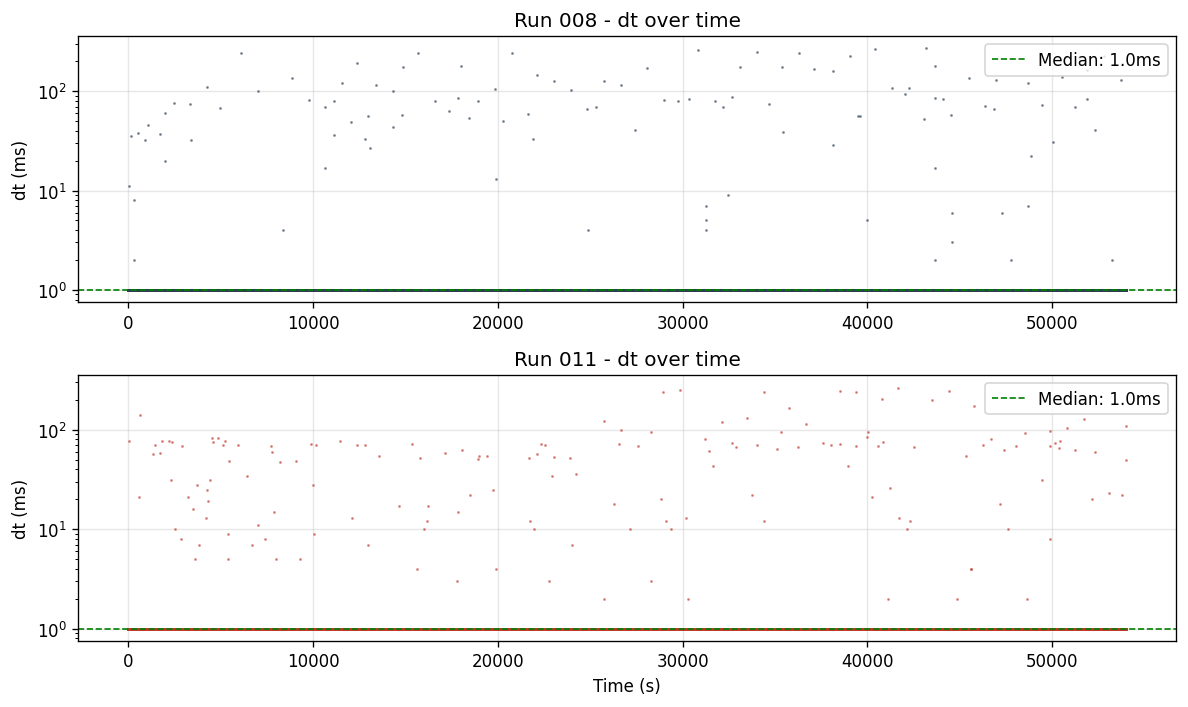

In [12]:
def analyze_dt(df):
    dt = df['t_ms'].diff().dropna().values
    dt_pos = dt[dt > 0]
    if len(dt_pos) == 0: return None, dt
    return float(np.median(dt_pos)), dt

med1, dt1 = analyze_dt(df1)
med2, dt2 = analyze_dt(df2)

FS1 = 1000.0 / med1 if med1 else NOMINAL_HZ
FS2 = 1000.0 / med2 if med2 else NOMINAL_HZ

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=False, sharey=True)

axes[0].plot(df1['time_s'].values[1:], dt1, '.', ms=1.5, color=CLR1['res'], alpha=0.5)
axes[0].axhline(med1, color='g', ls='--', lw=1, label=f'Median: {med1:.1f}ms')
axes[0].set_title(f'Run {RUN_ID_1} - dt over time')
axes[0].set_ylabel('dt (ms)')
axes[0].set_yscale('log')
axes[0].legend(loc='upper right')

axes[1].plot(df2['time_s'].values[1:], dt2, '.', ms=1.5, color=CLR2['res'], alpha=0.5)
axes[1].axhline(med2, color='g', ls='--', lw=1, label=f'Median: {med2:.1f}ms')
axes[1].set_title(f'Run {RUN_ID_2} - dt over time')
axes[1].set_ylabel('dt (ms)')
axes[1].set_xlabel('Time (s)')
axes[1].set_yscale('log')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

## 3. Basic Statistics

In [13]:
def get_stats(df, run_id):
    val = df['val'].values
    t = df['time_s'].values
    slope, intercept, _, _, _ = stats.linregress(t, val)
    res = val - (slope * t + intercept)
    return {
        'Run ID': run_id,
        f'Mean ({SENSOR_UNIT})': val.mean(),
        f'Std ({SENSOR_UNIT})': val.std(),
        f'Peak-to-Peak': val.max() - val.min(),
        f'Slope/s': slope,
        f'Std Detrended': res.std()
    }

stats_df = pd.DataFrame([get_stats(df1, RUN_ID_1), get_stats(df2, RUN_ID_2)])
display(stats_df.set_index('Run ID'))

,Mean (dBFS),Std (dBFS),Peak-to-Peak,Slope/s,Std Detrended
Run ID,,,,,
008,0.137601,0.081616,0.606482,-4.230036e-07,0.081349
011,0.113329,0.085060,0.607887,-1.791145e-06,0.080347


## 4. Time Series

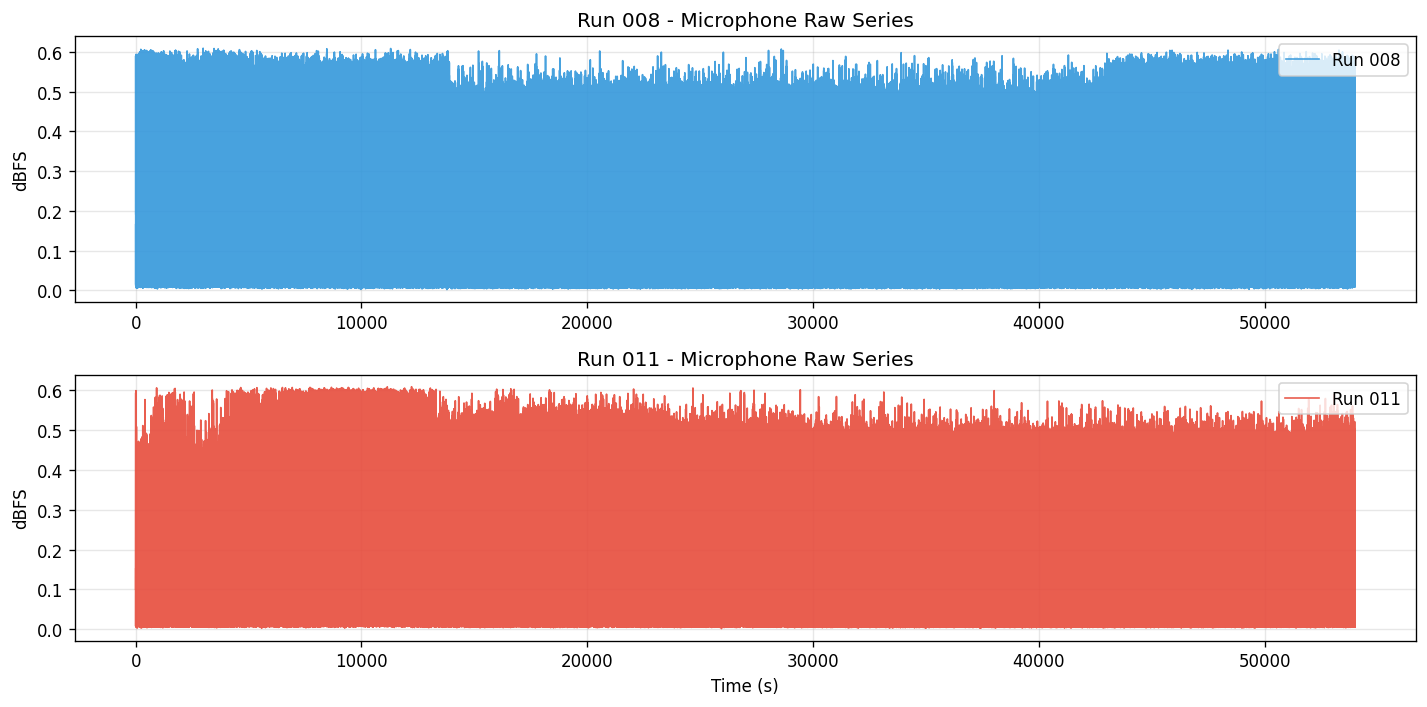

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=False, sharey=True)

axes[0].plot(df1['time_s'], df1['val'], color=CLR1['raw'], alpha=0.9, label=f'Run {RUN_ID_1}', rasterized=True)
axes[0].set_title(f'Run {RUN_ID_1} - {SENSOR_NAME} Raw Series')
axes[0].set_ylabel(SENSOR_UNIT)
axes[0].legend(loc='upper right')

axes[1].plot(df2['time_s'], df2['val'], color=CLR2['raw'], alpha=0.9, label=f'Run {RUN_ID_2}', rasterized=True)
axes[1].set_title(f'Run {RUN_ID_2} - {SENSOR_NAME} Raw Series')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel(SENSOR_UNIT)
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

## 5. Detrended Residuals

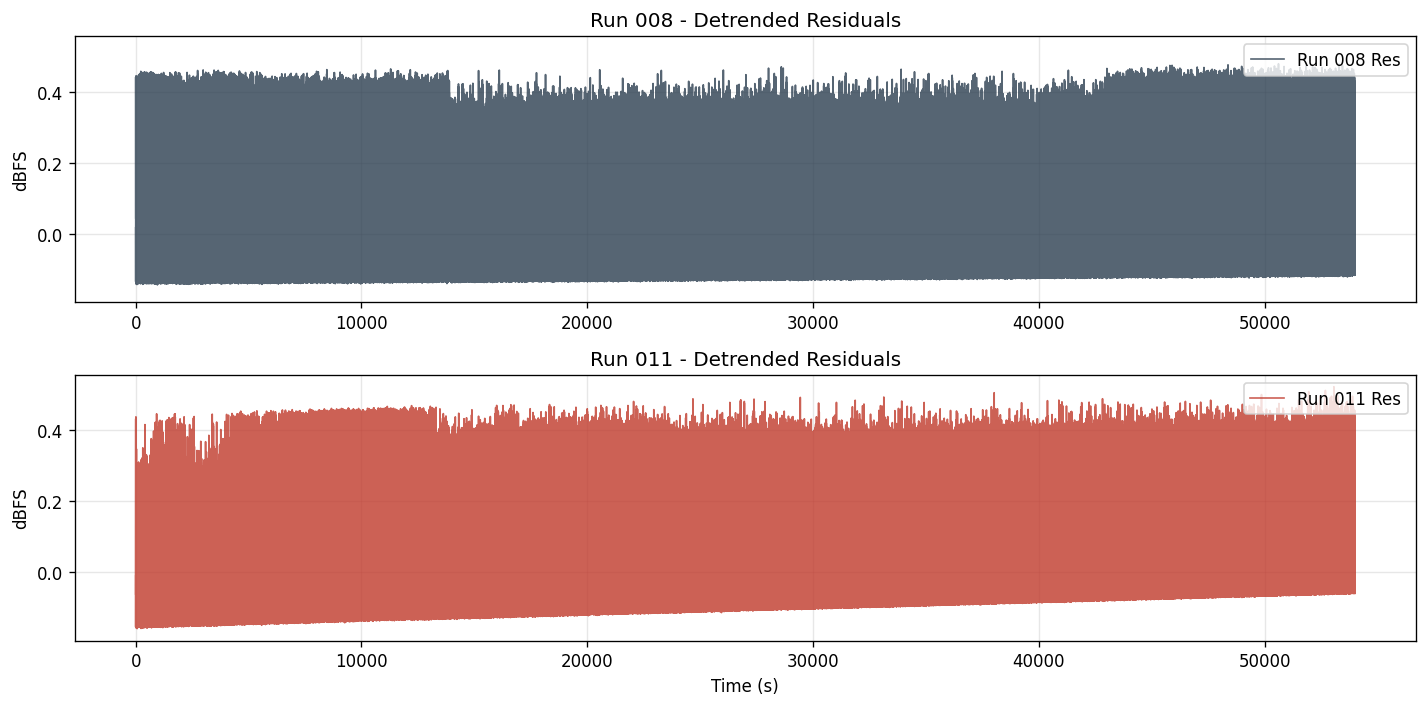

In [15]:
def get_residual(df):
    slope, intercept, _, _, _ = stats.linregress(df['time_s'], df['val'])
    return df['val'] - (slope * df['time_s'] + intercept)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=False, sharey=True)

axes[0].plot(df1['time_s'], get_residual(df1), color=CLR1['res'], alpha=0.8, label=f'Run {RUN_ID_1} Res', rasterized=True)
axes[0].set_title(f'Run {RUN_ID_1} - Detrended Residuals')
axes[0].set_ylabel(SENSOR_UNIT)
axes[0].legend(loc='upper right')

axes[1].plot(df2['time_s'], get_residual(df2), color=CLR2['res'], alpha=0.8, label=f'Run {RUN_ID_2} Res', rasterized=True)
axes[1].set_title(f'Run {RUN_ID_2} - Detrended Residuals')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel(SENSOR_UNIT)
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

## 6. Power Spectral Density (Welch PSD)

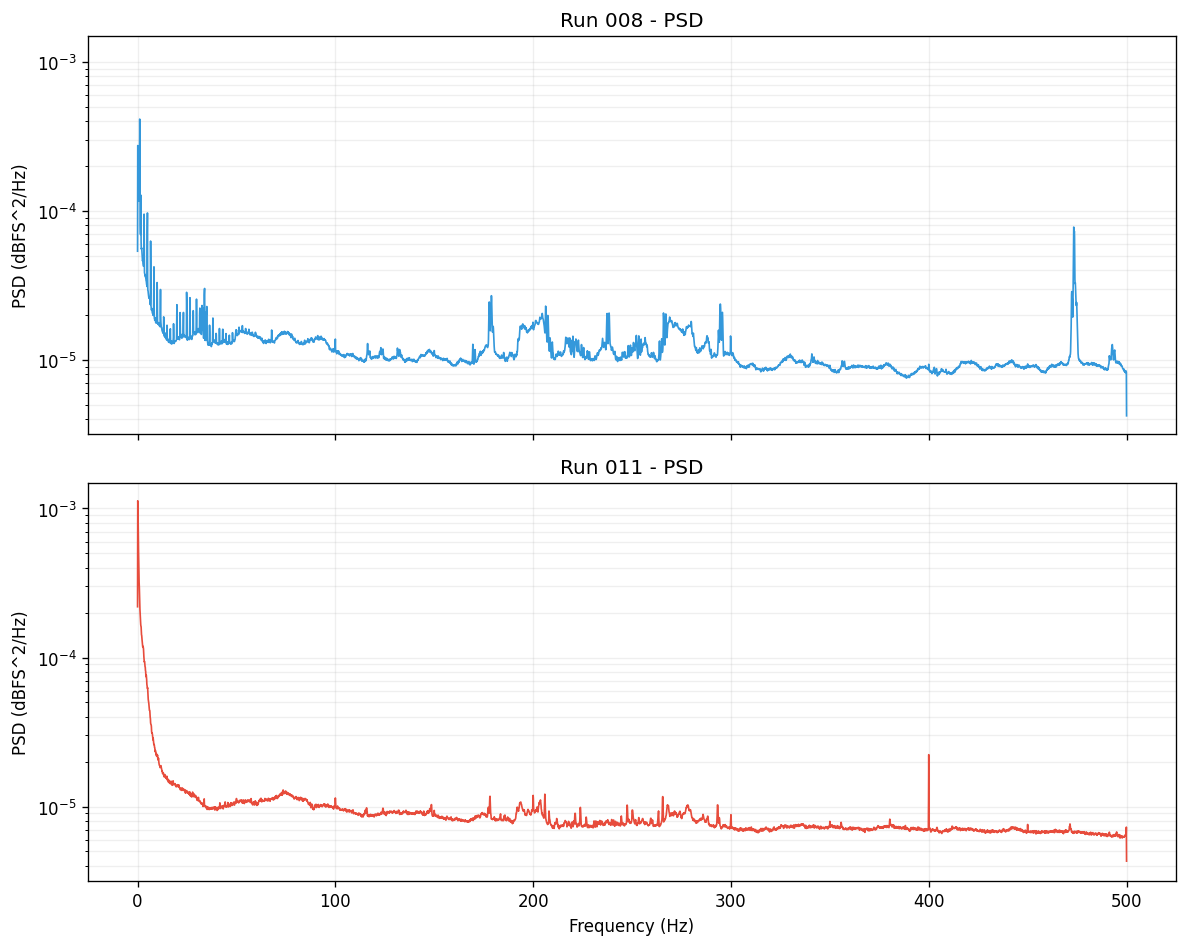

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True, sharey=True)

nperseg1 = min(len(df1), int(FS1 * 10))
if nperseg1 > 0:
    f1, Pxx1 = signal.welch(df1['val'].values, fs=FS1, nperseg=nperseg1)
    axes[0].semilogy(f1, Pxx1, color=CLR1['raw'])
axes[0].set_title(f'Run {RUN_ID_1} - PSD')
axes[0].set_ylabel(f'PSD ({SENSOR_UNIT}^2/Hz)')
axes[0].grid(True, which="both", ls="-", alpha=0.2)

nperseg2 = min(len(df2), int(FS2 * 10))
if nperseg2 > 0:
    f2, Pxx2 = signal.welch(df2['val'].values, fs=FS2, nperseg=nperseg2)
    axes[1].semilogy(f2, Pxx2, color=CLR2['raw'])
axes[1].set_title(f'Run {RUN_ID_2} - PSD')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel(f'PSD ({SENSOR_UNIT}^2/Hz)')
axes[1].grid(True, which="both", ls="-", alpha=0.2)

plt.tight_layout()
plt.show()

## 7. Allan Variance

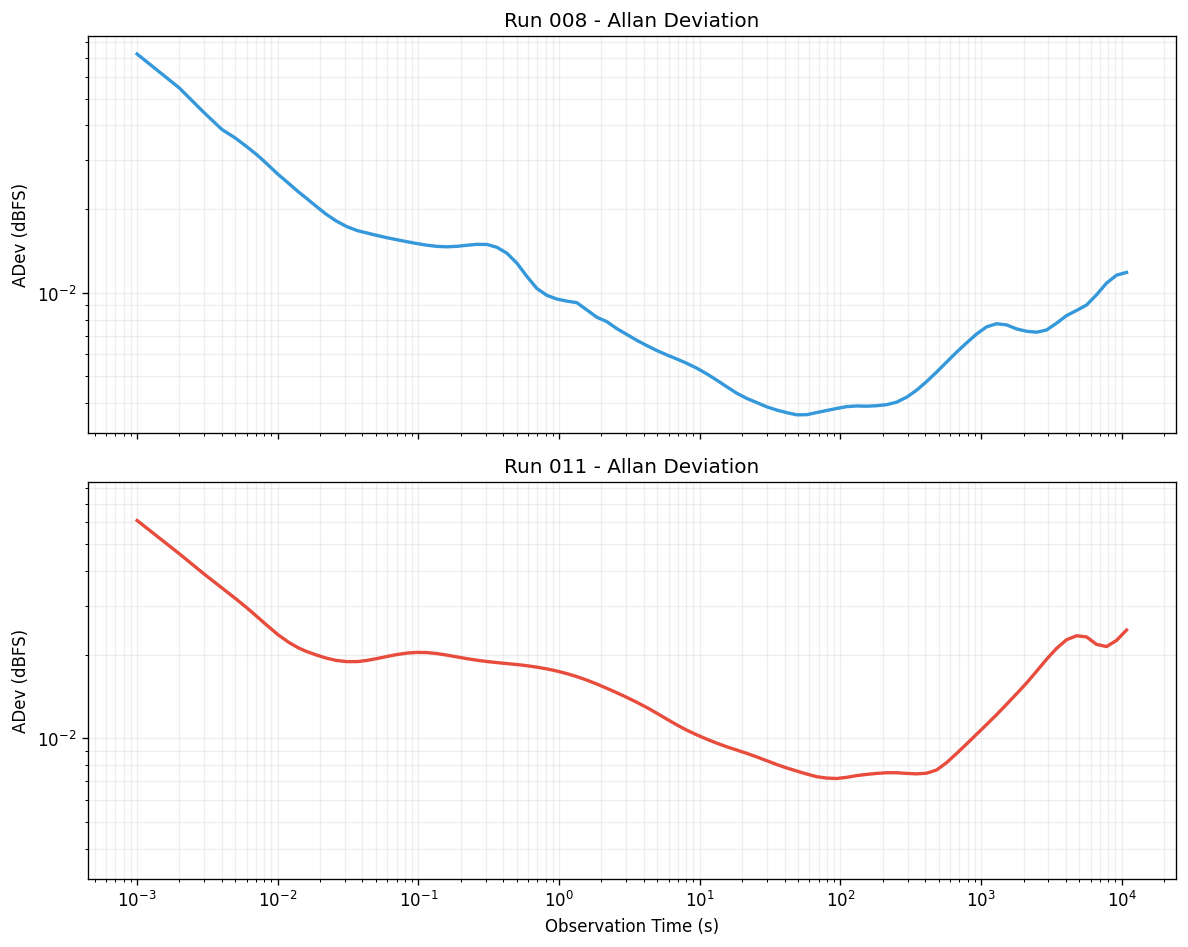

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True, sharey=True)

def plot_allan(ax, df, fs, run_id, color):
    dur = df['time_s'].iloc[-1]
    if dur > 1.0:
        tau = np.logspace(np.log10(1.0/fs), np.log10(dur/5), 100)
        try:
            t2, ad, _, _ = allantools.oadev(df['val'].values, rate=fs, data_type="freq", taus=tau)
            ax.loglog(t2, ad, color=color, lw=2)
            ax.set_title(f'Run {run_id} - Allan Deviation')
            ax.set_ylabel(f'ADev ({SENSOR_UNIT})')
            ax.grid(True, which="both", ls="-", alpha=0.2)
        except Exception as e:
            ax.set_title(f'Run {run_id} - Allan Variance failed')

plot_allan(axes[0], df1, FS1, RUN_ID_1, CLR1['raw'])
plot_allan(axes[1], df2, FS2, RUN_ID_2, CLR2['raw'])

axes[1].set_xlabel('Observation Time (s)')
plt.tight_layout()
plt.show()